Universidade do Vale do Itajaí<br>
PPGCA - Programa de Pós-Graduação em Computação Aplicada<br>
Aprendizado de Máquina<br>
Prof. Felipe Viel<br>
Conteúdo: Aprendizado por Reforço (AR)<br>

# Aprendizado por Reforço Clássico
## Q-Learning e SARSA com Gymnasium


### Objetivos

- Compreender o ambiente FrozenLake
- Implementar Q-Learning
- Implementar SARSA
- Comparar algoritmos On-Policy e Off-Policy
- Visualizar tabelas Q
- Visualizar políticas aprendidas
- Comparar ambientes determinísticos e estocásticos
- Explorar CliffWalking


## Pré-requisitos 
Antes de começar a usar o notebook, **você precisa entender**:
- Os fundamentos do aprendizado por reforço (MC, TD, hipótese de recompensa...) [Artigo](https://medium.freecodecamp.org/an-introduction-to-reinforcement-learning-4339519de419)
- Q-learning [Artigo](https://medium.freecodecamp.org/diving-deeper-into-reinforcement-learning-with-q-learning-c18d0db58efe)
- SARSA [Artigo](https://www.geeksforgeeks.org/machine-learning/sarsa-reinforcement-learning/)
- Exemplo de implementação: [vídeo](https://www.youtube.com/watch?v=q2ZOEFAaaI0) - no vídeo há a implementação de um agente de Q-learning que aprende a jogar OpenAI Taxi-v2 🚕 com Numpy.

## Importar dependências
Nós usamos 4 bibliotecas base:
- `Numpy` para trabalhar com Tabela Q
- `OpenAI Gymnasium` para usar os "jogos" FrozenLake Environment e CliffWalking - essa é a antiga lib gym
- `Matplotlib` para plotagem 
- `Seaborn` para plotagem

In [1]:

!pip -q install gymnasium seaborn matplotlib

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Explorando o FrozenLake

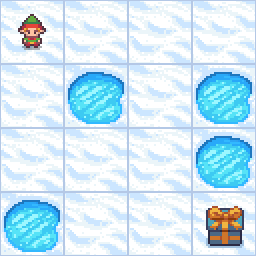

### Passo 1: Criar o ambiente
- Aqui, criaremos o ambiente FrozenLake.
- O OpenAI Gymnasium é uma biblioteca composta por diversos ambientes que podemos usar para treinar nossos agentes.
- No nosso caso, escolhemos usar o Frozen Lake.

In [ ]:

env = gym.make("FrozenLake-v1", is_slippery=False)

print("Estados:", env.observation_space.n)
print("Ações:", env.action_space.n)

print("\nMapa:")
print(env.unwrapped.desc)


Estados: 16
Ações: 4

Mapa:
[[b'S' b'F' b'F' b'F']
 [b'F' b'H' b'F' b'H']
 [b'F' b'F' b'F' b'H']
 [b'H' b'F' b'F' b'G']]



## Função ε-Greedy

Permite balancear:

- Exploração (ações aleatórias)
- Exploração do conhecimento adquirido


In [ ]:

def epsilon_greedy(Q, state, epsilon, env):

    if np.random.rand() < epsilon:
        return env.action_space.sample()

    #desempatamos ações aleatórias, principalmente quando o estado de 
    # escolha para todas as direções é Q[state] = [0,0,0,0] - como escolher ser tudo é zero?
    # então, argmax(Q[state]) não me ajuda muito para iniciar e se não iniciamos, como aprendemos?
    return np.random.choice(
        np.where(Q[state] == np.max(Q[state]))[0]
    )


## Passo 2: Criar a tabela Q e as funções Q-learning e SARSA e inicializá-la 🗄️
- Agora, vamos criar nossa tabela Q. Para saber quantas linhas (estados) e colunas (ações) precisamos, precisamos calcular o `action_size` e o `state_size`.
- O OpenAI Gymnasium nos fornece uma maneira de fazer isso: `env.action_space.n` e `env.observation_space.n`
- A função recebe um parametros de ambiente gerato (o jogo em si), número de episódios de treinamento e variáveis que influênciam o código (alpha, epsilon e gamma), além de varíavais que auxíliam no treinamento (decay, equivalente a taxa de aprendizagem, e min_epsilon, para inicializar o ajuste de erro)

### Observação
- Observe que o código do Q-learning e SARSA são pouco diferentes, sendo levado em conta o risco e otimização no Q-Learning e visão conservadora no SARSA

### Implementação do Q-Learning

In [ ]:

def train_qlearning(env, episodes=5000, alpha=0.1, gamma=0.99, epsilon=1.0, min_epsilon=0.01, decay=0.001):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards = []

    for ep in range(episodes):
        state, _ = env.reset()

        done = False
        total_reward = 0

        while not done:
            #aqui precisamos calcular a próxima ação com um grau de aleatoriedade
            action = epsilon_greedy(Q,state,epsilon,env)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            Q[state, action] += ??????
            state = ????
            total_reward += reward

        #necessário incluir para gerar "aleatoriedade" para iniciar a "caminhada pelo gelo"
        epsilon = max(min_epsilon, epsilon * np.exp(-decay))
        
        #só usamos para poder plotar e entender a evolução, não é necessário para o algoritmo
        rewards.append(total_reward)

    return Q, rewards


### Implementação do SARSA

In [ ]:

def train_sarsa(env, episodes=5000, alpha=0.1, gamma=0.99, epsilon=1.0, min_epsilon=0.01, decay=0.001):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards = []

    for ep in range(episodes):
        state, _ = env.reset()
        action = epsilon_greedy( Q, state, epsilon, env)
        done = False
        total_reward = 0

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            #aqui precisamos calcular a próxima ação com um grau de aleatoriedade
            next_action = epsilon_greedy(Q, next_state, epsilon, env)
            Q[state, action] += ?????
            state = ????
            action = ?????
            total_reward += reward

        #necessário incluir para gerar "aleatoriedade" para iniciar a "caminhada pelo gelo"
        epsilon = max(min_epsilon, epsilon * np.exp(-decay))
        
        #só usamos para poder plotar e entender a evolução, não é necessário para o algoritmo
        rewards.append(total_reward)

    return Q, rewards


## Treinamento
- Aqui treinamos o modelo e capturamos a nossa Tabela Q (onde guardamos o "aprendizado") e também as evolução das recompensas obtidas para alcaçar o objetivo

In [6]:

Q_qlearning, rewards_q = train_qlearning(env)

Q_sarsa, rewards_sarsa = train_sarsa(env)


## Comparação de Convergência

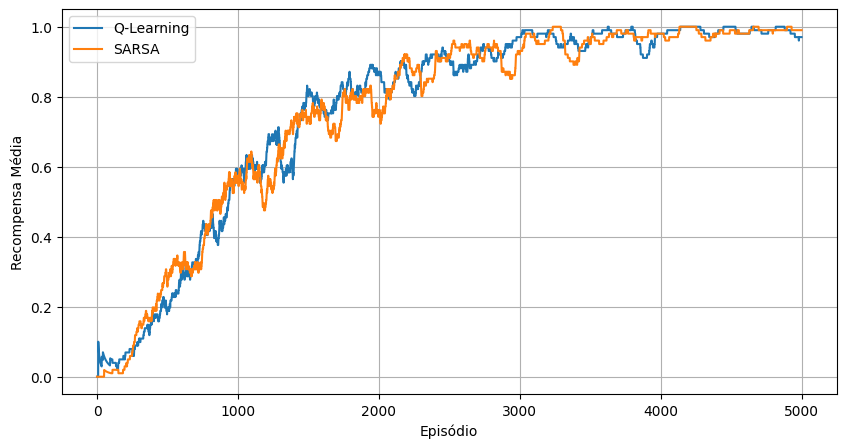

In [ ]:

window = 100

avg_q = [np.mean(rewards_q[max(0,i-window):i+1]) for i in range(len(rewards_q))]

avg_s = [np.mean(rewards_sarsa[max(0,i-window):i+1]) for i in range(len(rewards_sarsa))]

plt.figure(figsize=(10,5))

plt.plot(avg_q,label="Q-Learning")
plt.plot(avg_s,label="SARSA")

plt.legend()
plt.grid()

plt.xlabel("Episódio")
plt.ylabel("Recompensa Média")

plt.show()


## Heatmap da Tabela Q - Q-Learning

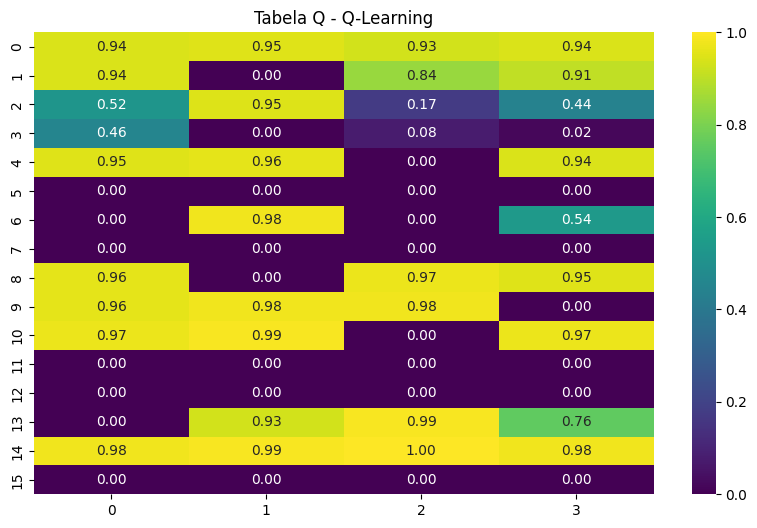

In [ ]:

plt.figure(figsize=(10,6))
sns.heatmap(Q_qlearning, annot=True, fmt=".2f", cmap="viridis")
plt.title("Tabela Q - Q-Learning")
plt.show()


## Heatmap da Tabela Q - SARSA

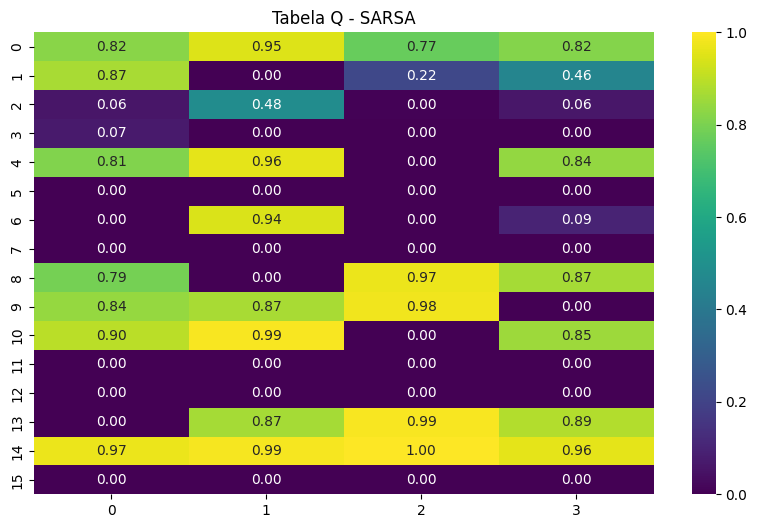

In [ ]:

plt.figure(figsize=(10,6))
sns.heatmap(Q_sarsa, annot=True, fmt=".2f", cmap="viridis")
plt.title("Tabela Q - SARSA")
plt.show()


## Política Aprendida

In [ ]:
# pode usar https://pt.wikipedia.org/wiki/Seta_(s%C3%ADmbolo)
actions = {0:'←', 1:'↓',2:'→',3:'↑'}

policy_q = [actions[np.argmax(Q_qlearning[state])] for state in range(env.observation_space.n)]

policy_s = [actions[np.argmax(Q_sarsa[state])] for state in range(env.observation_space.n)]

print("Q-Learning")
print(np.array(policy_q).reshape(4,4))

print("\nSARSA")
print(np.array(policy_s).reshape(4,4))


Q-Learning
[['↓' '←' '↓' '←']
 ['↓' '←' '↓' '←']
 ['→' '→' '↓' '←']
 ['←' '→' '→' '←']]

SARSA
[['↓' '←' '↓' '←']
 ['↓' '←' '↓' '←']
 ['→' '→' '↓' '←']
 ['←' '→' '→' '←']]


## FrozenLake Estocástico

In [ ]:

env_stochastic = gym.make("FrozenLake-v1", is_slippery=True)

Q_stochastic, rewards_stochastic = train_qlearning(env_stochastic, episodes=10000)

print("Treinamento concluído.")


Treinamento concluído.


## CliffWalking

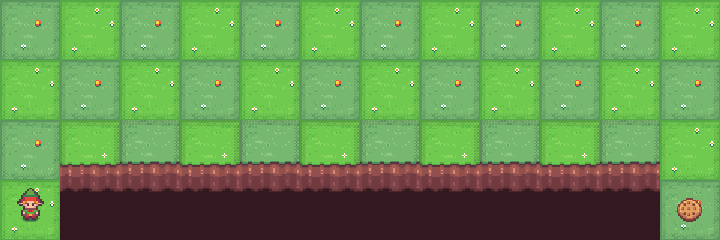

In [ ]:

env_cliff = gym.make("CliffWalking-v1")
Q_cliff_q, rewards_cliff_q = train_qlearning(env_cliff, episodes=1000)
Q_cliff_s, rewards_cliff_s = train_sarsa(env_cliff, episodes=1000)


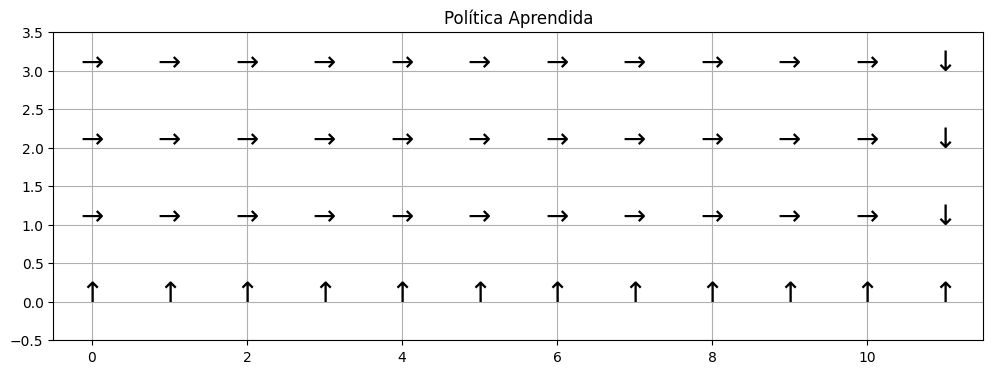

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

actions = {0:'↑',1:'→',2:'↓',3:'←'}

policy = []

for state in range(env.observation_space.n):

    policy.append(actions[np.argmax(Q_cliff_q[state])])

policy = np.array(policy).reshape(4,12)

plt.figure(figsize=(12,4))

for i in range(4):
    for j in range(12):

        plt.text(j, 3-i, policy[i,j], fontsize=20, ha='center')

plt.xlim(-0.5,11.5)
plt.ylim(-0.5,3.5)

plt.grid()
plt.title("Política Aprendida")

plt.show()

In [ ]:
from IPython.display import clear_output
import time

env = gym.make(
    "CliffWalking-v1",
    render_mode="ansi"
)

state, _ = env.reset()

done = False

while not done:

    clear_output(wait=True)
    print(env.render())
    action = np.argmax(Q_cliff_q[state])
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    time.sleep(0.4)

print("Objetivo alcançado")

o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  o
o  o  o  o  o  o  o  o  o  o  o  x
o  C  C  C  C  C  C  C  C  C  C  T


Objetivo alcançado


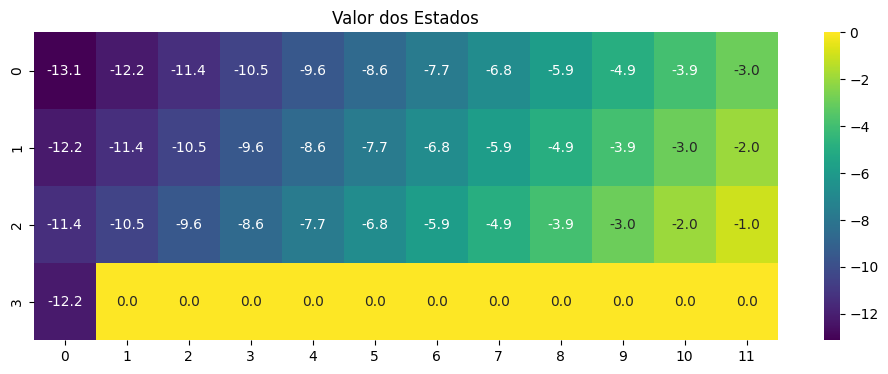

In [ ]:
import seaborn as sns

values = np.max(Q_cliff_q, axis=1)
values = values.reshape(4,12)

plt.figure(figsize=(12,4))
sns.heatmap(values, annot=True, fmt=".1f", cmap="viridis")
plt.title("Valor dos Estados")
plt.show()


# Exercícios Propostos

## Exercício 1
Alterar γ para:

- 0.5
- 0.8
- 0.99

### Dica
Modificar o parâmetro:

```python
gamma=...
```

Observe como muda a importância das recompensas futuras.

---

## Exercício 2
Alterar α para:

- 0.01
- 0.5

### Dica

Modificar:

```python
alpha=...
```

Compare velocidade de convergência e estabilidade.

---

## Exercício 3
Comparar:

- ε constante
- ε decrescente

### Dica

Comente:

```python
epsilon = max(...)
```

e utilize um valor fixo.

---

## Exercício 4
Treinar FrozenLake 8x8

### Dica

Substituir:

```python
gym.make("FrozenLake-v1")
```

por:

```python
gym.make(
    "FrozenLake-v1",
    map_name="8x8"
)
```

Compare o tempo necessário para aprender.

---

## Exercício 5
Implementar Double Q-Learning

### Dica

Criar duas tabelas:

```python
Q1
Q2
```

e alternar as atualizações.

---

## Exercício 6
Comparar FrozenLake e Taxi-v3

### Dica

Utilizar:

```python
env = gym.make("Taxi-v3")
```

Comparar:

- número de estados
- velocidade de convergência
- política aprendida

---

## Exercício 7
Calcular Taxa de Sucesso

### Dica

Executar 100 episódios sem exploração:

```python
epsilon = 0
```

e calcular:

```python
sucessos / total_episodios
```

Obtendo a performance final do agente.


# Hora da nostalgia

Como forma de aplicarmos o algoritmo Q-Learning em um jogo "mais gráfico". Neste [LINK](https://pooyanjamshidi.github.io/csce580/project3/#Q9) há um projeto comumente usado para ensinar IA, em especial a questão 9 para ensinar Aprendizado por Reforço com o algoritmo Q-Learning. Fica o desafio para aplicar os códigos anteriores de forma a conseguier fazer o Pac-man aprender a fugir dos fantasmas por meio do aprendizado por reforço. O código fonte pode ser baixodo nesse [LINK](https://pooyanjamshidi.github.io/csce580/project3/reinforcement.zip)

# Exemplos de outros algoritmos 

## Policy Gradient

In [ ]:
import torch
import torch.nn as nn

policy = nn.Sequential(
    nn.Linear(4,128),
    nn.ReLU(),
    nn.Linear(128,2),
    nn.Softmax(dim=-1)
)

state = torch.tensor([0.1,0.2,0.3,0.4])

probs = policy(state)

action = torch.multinomial(probs,1)

log_prob = torch.log(probs[action])

reward = 10

loss = -log_prob * reward

loss.backward()

## Reinforce

In [ ]:
optimizer = torch.optim.Adam(
    policy.parameters(),
    lr=1e-3
)

returns = []

G = 0

for r in reversed(rewards):
    G = r + 0.99 * G
    returns.insert(0,G)

loss = []

for log_prob,G in zip(log_probs,returns):
    loss.append(-log_prob*G)

loss = torch.stack(loss).sum()

optimizer.zero_grad()
loss.backward()
optimizer.step()

## Actor-Critic

In [ ]:
import torch
import torch.nn as nn

class ActorCritic(nn.Module):

    def __init__(self):
        super().__init__()

        self.shared = nn.Linear(4,128)

        self.actor = nn.Linear(128,2)

        self.critic = nn.Linear(128,1)

    def forward(self,x):

        h = torch.relu(self.shared(x))

        probs = torch.softmax(
            self.actor(h),
            dim=-1
        )

        value = self.critic(h)

        return probs,value

### Treinamento

In [ ]:
probs,value = model(state)

action = torch.multinomial(
    probs,
    1
)

next_probs,next_value = model(next_state)

td_target = reward + gamma*next_value

delta = td_target - value

actor_loss = (
    -torch.log(probs[action])
    * delta.detach()
)

critic_loss = delta.pow(2)

loss = actor_loss + critic_loss